# Introduction to structural equation models in CORNETO

A **structural equation model (SEM)** describes a system through one equation for each variable. Each equation expresses that variable as a function of its parent variables and a noise term representing variation not explained by those parents. For example,

$$
B = 2A + \varepsilon_B
$$

describes a linear relationship between $A$ and $B$, with additional variation captured by $\varepsilon_B$. A directed graph records which variables appear as parents in each equation; the equations specify how those inputs determine the resulting values.

A **structural causal model (SCM)** gives these equations a causal interpretation: they describe mechanisms through which variables influence one another. This interpretation allows us to represent interventions by changing a mechanism—for example, replacing the equation for $A$ with a fixed value—and simulate the consequences for downstream variables. A SEM does not automatically have this causal meaning; it depends on the assumptions behind the model.

CORNETO combines data with a **prior knowledge network** to fit structural equation models. `LinearDAGDiscovery` performs causal discovery by fitting a linear, acyclic structural causal model constrained by that network. It combines measurements with hard or shift intervention annotations to select relationships and estimate their coefficients. As with other causal discovery methods, recovering the underlying causal structure depends on the modeling assumptions and the information available in the data.

This guide introduces these modeling concepts using CORNETO's simple SCM simulator. We specify the graph, equations, and noise distributions ourselves, then generate synthetic observations and intervention data. Because the generating model is known, these data can be used to test fitting methods and compare their results with the underlying model.

We begin with a small three-variable system, explore linear and nonlinear equations, and show how to package the simulated measurements and intervention information as CORNETO `Data`. Fitting a model is covered in the companion guide on [linear DAG discovery](linear-dag-discovery.ipynb).

In the example, `A` is an upstream variable, `B` depends on `A`, and `C` depends on both. The equations and coefficients are chosen to illustrate the simulator rather than represent a particular biological system.

## Set up the notebook

We will use CORNETO's `Graph.plot` to draw the pathway, pandas to organize the measurements, and Matplotlib to plot the simulated values. The imported Jupyter `display()` function shows a table with notebook formatting, including when a cell needs to show more than one result. The CORNETO Pixi environment includes these packages. If you are using another Python environment, install CORNETO's plotting extra, pandas, and Matplotlib, and make sure the Graphviz program is installed.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from corneto.data import Data
from corneto.graph import Graph
from corneto.methods.causal.simulation import Additive, Linear, Node, Normal, SCM, linear_scm

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

POSITIVE = "#16856b"
NEGATIVE = "#dc7448"
NEUTRAL = "#62748a"
node_style = {
    "shape": "box",
    "style": "rounded,filled",
    "fillcolor": "#edf3f8",
    "color": "#43566b",
    "fontcolor": "#213247",
    "fontname": "Helvetica",
    "fontsize": "11",
    "margin": "0.16,0.09",
}
graph_style = {
    "rankdir": "LR",
    "ranksep": "0.8",
    "nodesep": "0.45",
    "splines": "spline",
    "pad": "0.2",
    "bgcolor": "transparent",
}

## Define the structural equations

For each simulated sample, the model draws a random noise value for each variable. Think of these noise values as background variation between samples that the simple model does not describe. The three equations are:

- `A = noise_A`: nothing else in this example causes `A`, so each sample's value is just random variation.
- `B = 2 × A + noise_B`: if `A` is one unit higher, `B` is expected to be two units higher. `noise_B` allows samples with the same `A` to have different `B` values.
- `C = tanh(A × B) + noise_C`: `C` depends on both `A` and `B`. The `tanh` function keeps their combined effect within a limited range, and `noise_C` adds more sample-to-sample variation.

A `Node` stores an equation, the names of the variables used by that equation, and a rule for drawing its noise. Those input variables are called the node's **parents**. For `C`, the parent order is `A` then `B`, so the first parent column is `A` and the second is `B`. `Additive` means “evaluate this function, then add the noise.”

In [2]:
parent_graph = Graph.from_tuples([
    ("A", 1, "B"),
    ("A", 1, "C"),
    ("B", 1, "C"),
])

scm = SCM({
    "A": Node((), lambda parents, noise: noise, Normal()),
    "B": Node(("A",), Linear((2.0,)), Normal(std=0.5)),
    "C": Node(
        ("A", "B"),
        Additive(lambda parents: np.tanh(parents[:, 0] * parents[:, 1])),
        Normal(std=0.2),
    ),
})

This diagram is a map of the equations: an arrow into `B` means that the rule for `B` uses `A`. An arrow into `C` means that its rule uses that parent too. The arrows show which values feed into each equation; the equations in the code say how large those effects are.

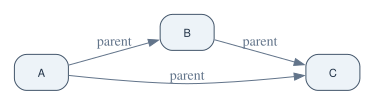

In [3]:
parent_graph.plot(
    renderer="graphviz",
    graph_attr=graph_style,
    node_attr=node_style,
    custom_edge_attr={
        index: {"label": "parent", "color": NEUTRAL, "fontcolor": NEUTRAL}
        for index in range(parent_graph.num_edges)
    },
)

## Generate observations

`sample(1_000)` creates 1,000 synthetic samples. It returns a NumPy table: each row is one sample, and each column is a variable. The columns are in the order listed by `scm.variables`. We put those names on the columns so the first few records are easy to read.

In [4]:
observations = scm.sample(1_000, rng=7)
observation_df = pd.DataFrame(observations, columns=scm.variables)
observation_df.insert(0, "regime", "observation")
print(f"{len(observation_df):,} simulated observations")
display(observation_df.head())

1,000 simulated observations


,regime,A,B,C
0,observation,0.001230,0.181862,-0.072903
1,observation,0.298746,0.793288,0.301014
2,observation,-0.274138,-0.758616,0.171950
3,observation,-0.890592,-0.770739,0.417827
4,observation,-0.454671,-0.723822,0.475249


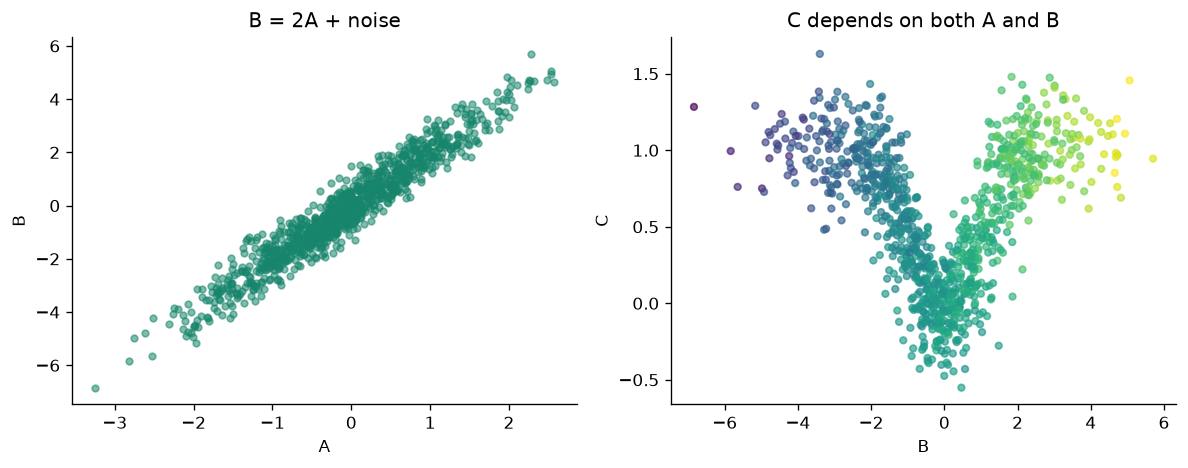

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(observation_df["A"], observation_df["B"], s=16, alpha=0.55, color=POSITIVE)
axes[0].set(xlabel="A", ylabel="B", title="B = 2A + noise")
axes[1].scatter(
    observation_df["B"], observation_df["C"],
    c=observation_df["A"], cmap="viridis", s=16, alpha=0.65,
)
axes[1].set(xlabel="B", ylabel="C", title="C depends on both A and B")
fig.tight_layout()
plt.show()

## Edit the baseline model

Suppose we decide to try a different rule for the outcome `C`: instead of the curved `tanh` relationship, let `C` be a weighted sum of `A` and `B`. `Node.replace()` lets us change that equation while keeping the same parents. `SCM.replace()` makes a new model containing the edited node.

The original `scm` is left as it was. This edit defines a new usual model for generating data. It does not represent an experiment in which we deliberately set a variable's value, so it is not labeled as an intervention.

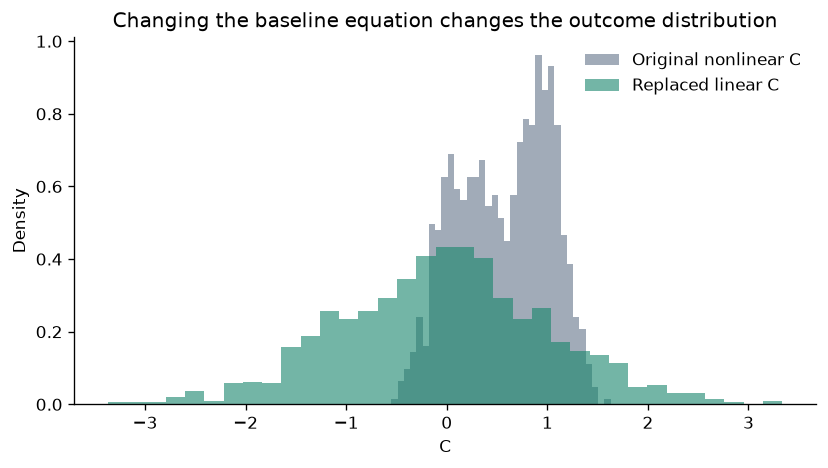

{'id': 'C', 'value': -1.8779414627163178, 'mapping': 'vertex'}

In [6]:
custom_c = scm.nodes["C"].replace(
    mechanism=Linear((0.5, 0.25)),
    noise=Normal(std=0.1),
)
custom_baseline = scm.replace({"C": custom_c})
custom_values = custom_baseline.sample(1_000, rng=8)
custom_df = pd.DataFrame(custom_values, columns=custom_baseline.variables)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(observation_df["C"], bins=35, density=True, alpha=0.6, color=NEUTRAL, label="Original nonlinear C")
ax.hist(custom_df["C"], bins=35, density=True, alpha=0.6, color=POSITIVE, label="Replaced linear C")
ax.set(xlabel="C", ylabel="Density", title="Changing the baseline equation changes the outcome distribution")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

custom_data = custom_baseline.sample_data(
    3, rng=8, sample_ids=["edited_0", "edited_1", "edited_2"]
)
custom_data.samples["edited_0"].features[2].data

## Define parent relationships with a CORNETO graph

The graph can provide the list of parent relationships, while we provide the equation for each variable. `SCM.from_graph()` reads the incoming arrows to decide which parent values each equation receives. We still need to give it one mechanism for every graph vertex. A vertex with no incoming arrows, such as `A`, is a root: its equation gets no parent values, but it can still have random noise.

The order of a vertex's incoming arrows determines the order of its parent columns. In the following example, this graph-based model uses the same equations as the earlier `SCM` built from `Node` objects.

In [7]:
graph_scm = SCM.from_graph(
    parent_graph,
    mechanisms={
        "A": lambda parents, noise: noise,
        "B": Linear((2.0,)),
        "C": Additive(lambda parents: np.tanh(parents[:, 0] * parents[:, 1])),
    },
    noises=Normal(std=0.2),
)

from_graph_values = graph_scm.sample(5, rng=9)
pd.DataFrame(from_graph_values, columns=graph_scm.variables)

,A,B,C
0,-0.160567,-0.411657,-0.340508
1,0.048570,0.183237,0.290984
2,-0.331269,-0.612352,0.190589
3,0.131221,0.183572,0.528549
4,0.228691,0.284900,0.230306


## Build a linear model

When every equation is a weighted sum of its parents plus noise, `linear_scm()` can build the model for us. For example, `("A", "B"): 1.5` means that the equation for `B` includes `1.5 × A`. The `weights` dictionary gives the exact coefficients used in the equations.

The graph's edge sign and the coefficient are different things. A sign says whether the relationship is positive or negative. The coefficient also gives its size. The simulator reads coefficient values from `weights`; it does not treat a graph sign as a coefficient magnitude.

If we leave out `weights`, `linear_scm()` chooses positive and negative coefficients at random. By default, their sizes are between 0.5 and 2 so they are not almost zero. The `rng=12` in the code fixes those coefficient choices. It is separate from the random seed used later to generate samples.

In [8]:
linear_graph = Graph.from_tuples([
    ("A", 1, "B"),
    ("A", -1, "C"),
    ("B", 1, "C"),
])
weights = {
    ("A", "B"): 1.5,
    ("A", "C"): -0.4,
    ("B", "C"): 0.8,
}
truth = linear_scm(
    linear_graph,
    weights=weights,
    biases={"C": 0.1},
    noise=Normal(std=0.15),
)

random_model = linear_scm(linear_graph, rng=12, noise=Normal(std=0.15))
random_weights = {
    (parent, child): coefficient
    for child, node in random_model.nodes.items()
    for parent, coefficient in zip(node.parents, node.mechanism.weights, strict=True)
}
display(pd.DataFrame([
    {"parent": parent, "child": child, "random coefficient": coefficient}
    for (parent, child), coefficient in random_weights.items()
]))

,parent,child,random coefficient
0,A,B,-0.876237
1,A,C,-1.920129
2,B,C,0.783981


Each arrow label in this diagram is one of the numbers in `weights`. Green arrows increase the child variable when the parent increases; orange arrows decrease it. For example, the `-0.4` arrow from `A` to `C` means that, with other inputs held fixed, increasing `A` by one lowers `C` by `0.4`.

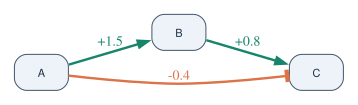

In [9]:
edge_order = [
    (next(iter(source)), next(iter(target)))
    for source, target in linear_graph.E
]
edge_styles = {
    index: {
        "label": f"{weights[edge]:+.1f}",
        "color": POSITIVE if weights[edge] > 0 else NEGATIVE,
        "fontcolor": POSITIVE if weights[edge] > 0 else NEGATIVE,
        "penwidth": "2.4",
    }
    for index, edge in enumerate(edge_order)
}
linear_graph.plot(
    renderer="graphviz",
    graph_attr=graph_style,
    node_attr=node_style,
    custom_edge_attr=edge_styles,
)

## Simulate hard and shift interventions

The ordinary equation for `A` is `A = noise_A`. With `truth.do({"A": 2.0})`, we replace that equation with `A = 2.0`. Every sample now has `A` exactly equal to 2. The usual random value for `A` is ignored. This is a **hard intervention**: we deliberately set the variable itself to one fixed value.

With `truth.shift({"A": 1.0})`, we keep the ordinary equation and add one to its result. The equation becomes `A = noise_A + 1`. A sample whose ordinary `A` would have been `-0.2` now has `A = 0.8`; a sample whose ordinary value would have been `0.5` now has `A = 1.5`. All values increase by one, but variation between samples is preserved. This is a **shift intervention**.

Both operations create a new SCM; neither changes `truth`. The next cell compares the usual model, the fixed-value model, and the shifted model using the same random noise values. That means we are comparing paired samples with the same background variation. If we drew new noise for each intervention, a difference in `C` could come from either the intervention or the new noise draws. Reusing the noise holds those background differences steady, so the change in each sample's outcome comes from the intervention.

In this example, a one-unit increase in `A` changes `C` along two routes. The direct arrow `A → C` contributes `-0.4`. The route `A → B → C` contributes `1.5 × 0.8 = 1.2`. Adding the routes gives `-0.4 + 1.2 = 0.8`. The code checks that every paired simulation has exactly this change.

In [10]:
noise = truth.draw_noise(500, rng=31)
usual = truth.evaluate(noise)
hard_clamp = truth.do({"A": 2.0}).evaluate(noise)
shifted = truth.shift({"A": 1.0}).evaluate(noise)

column_c = truth.variables.index("C")
shift_effect = shifted[:, column_c] - usual[:, column_c]
expected_shift_effect = weights[("A", "C")] + weights[("A", "B")] * weights[("B", "C")]
np.testing.assert_allclose(shift_effect, expected_shift_effect)
print(f"Exact paired effect of shift(A=+1) on C: {shift_effect.mean():+.2f}")

Exact paired effect of shift(A=+1) on C: +0.80


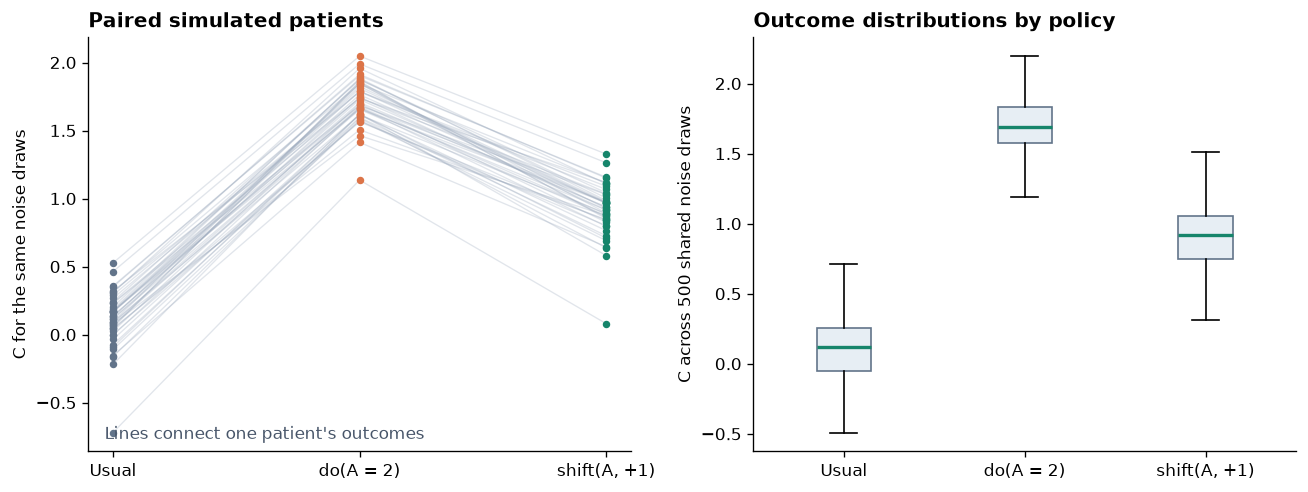

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
regime_values = [usual[:, column_c], hard_clamp[:, column_c], shifted[:, column_c]]
regime_names = ["Usual", "do(A = 2)", "shift(A, +1)"]
for index in range(45):
    axes[0].plot(range(3), [values[index] for values in regime_values], color="#94a3b8", alpha=0.28, linewidth=0.8)
for position, values, color in zip(range(3), regime_values, [NEUTRAL, NEGATIVE, POSITIVE], strict=True):
    axes[0].scatter([position] * 45, values[:45], color=color, s=12, zorder=3)
axes[0].set_xticks(range(3), regime_names)
axes[0].set_ylabel("C for the same noise draws")
axes[0].set_title("Paired simulated patients", loc="left", fontweight="bold")
axes[0].text(0.03, 0.03, "Lines connect one patient's outcomes", transform=axes[0].transAxes, color="#475569")

axes[1].boxplot(regime_values, tick_labels=regime_names, patch_artist=True, showfliers=False,
                boxprops={"facecolor": "#e7eef4", "edgecolor": "#62748a"},
                medianprops={"color": POSITIVE, "linewidth": 2})
axes[1].set_ylabel("C across 500 shared noise draws")
axes[1].set_title("Outcome distributions by policy", loc="left", fontweight="bold")
fig.tight_layout()
plt.show()

## Store simulated data in CORNETO Data

A NumPy array is convenient for calculations, but it does not say which rows were observations and which rows came from an experiment. CORNETO `Data` stores samples together with information about their features.

Here we make six samples under each of three conditions: ordinary observations, setting `A` to 2, and adding 1 to the usual `A`. `sample_data()` records whether the changed feature was set to a fixed value or shifted, along with the group name we provide. Ordinary observations have no intervention label because we did not change their equations.

In [12]:
observed_data = truth.sample_data(
    6, rng=41, sample_ids=[f"obs_{i}" for i in range(6)]
)
hard_data = truth.do({"A": 2.0}).sample_data(
    6, rng=42,
    sample_ids=[f"hard_{i}" for i in range(6)],
    intervention_group="do_A_2",
)
shift_data = truth.shift({"A": 1.0}).sample_data(
    6, rng=43,
    sample_ids=[f"shift_{i}" for i in range(6)],
    intervention_group="shift_A_plus_1",
)
data = Data.from_dict({
    **observed_data.to_dict(),
    **hard_data.to_dict(),
    **shift_data.to_dict(),
})

In [13]:
def data_to_frame(data, variables):
    rows = []
    for sample_id, sample in data.samples.items():
        features = {feature.id: feature for feature in sample.features}
        intervention_features = [
            feature for feature in sample.features
            if feature.data.get("intervention") is not None
        ]
        target = intervention_features[0] if intervention_features else None
        if target is None:
            regime = "observation"
            group = "observational"
            target_name = "—"
            shift_amount = np.nan
        else:
            kind = target.data["intervention"]
            regime = "hard intervention" if kind == "hard" else "known shift"
            group = target.data.get("intervention_group", regime)
            target_name = target.id
            shift_amount = target.data.get("shift", np.nan)
        row = {
            "sample_id": sample_id,
            "regime": regime,
            "intervention_group": group,
            "target": target_name,
            "shift": shift_amount,
        }
        row.update({variable: features[variable].value for variable in variables})
        rows.append(row)
    return pd.DataFrame.from_records(rows)

data_df = data_to_frame(data, truth.variables)
print(f"CORNETO Data: {len(data_df)} samples; {len(truth.variables)} measured variables")
display(data_df.groupby(["regime", "intervention_group"], sort=False).size().rename("samples").to_frame())
display(data_df.head(12).set_index("sample_id"))

CORNETO Data: 18 samples; 3 measured variables


,,samples
regime,intervention_group,
observation,observational,6
hard intervention,do_A_2,6
known shift,shift_A_plus_1,6


,regime,intervention_group,target,shift,A,B,C
sample_id,,,,,,,
obs_0,observation,observational,—,NaN,-0.184750,-0.263061,0.097631
obs_1,observation,observational,—,NaN,0.040068,-0.115521,-0.090051
obs_2,observation,observational,—,NaN,-0.001039,-0.205294,-0.145808
obs_3,observation,observational,—,NaN,0.075230,-0.083139,0.292835
obs_4,observation,observational,—,NaN,-0.199009,-0.406156,-0.009903
obs_5,observation,observational,—,NaN,0.166165,0.427091,0.254698
hard_0,hard intervention,do_A_2,A,NaN,2.000000,3.045708,1.755742
hard_1,hard intervention,do_A_2,A,NaN,2.000000,2.844002,1.527766
hard_2,hard intervention,do_A_2,A,NaN,2.000000,3.112568,1.787534


The pandas table is a readable view of the same CORNETO `data` object. The first columns explain how each row was generated; the remaining columns contain the measured values of `A`, `B`, and `C`. A downstream CORNETO method should receive `data`, not this display-only table.

In a shift sample, the `A` feature stores the intervention kind, the amount added, and the group name. The next cell shows those fields for one sample.

In [14]:
shifted_a = next(feature for feature in data.samples["shift_0"] if feature.id == "A")
shifted_a.data

{'id': 'A',
 'value': 1.036634426000764,
 'mapping': 'vertex',
 'intervention': 'shift',
 'shift': 1.0,
 'intervention_group': 'shift_A_plus_1'}

## Simulate a custom mechanism intervention

Sometimes an experiment changes a variable in a way that cannot be described by fixing it to one number or adding a known amount. For example, we can replace the equation for `C` with the alternative rule we made earlier. `intervene()` creates a model for this custom experiment, and the simulator can generate values from it.

The intervention labels understood by `LinearDAGDiscovery` currently cover the two cases from the previous section: a fixed value and a known shift. They do not describe every possible equation change. For that reason, converting this custom experiment with `sample_data()` raises an error. This prevents the data from being mislabeled as a fixed-value or shift intervention.

In [15]:
mechanism_intervention = scm.intervene({"C": custom_c})
experimental_values = mechanism_intervention.sample(100, rng=9)
print("Experimental simulation shape:", experimental_values.shape)
try:
    mechanism_intervention.sample_data(5, rng=9)
except ValueError as error:
    print(error)

Experimental simulation shape: (100, 3)
Cannot convert arbitrary node interventions to LinearDAGDiscovery data; intervention metadata is unsupported for ('C',).


## From simulation to fitting

The simulator generates data from a model whose parent relationships, mechanisms, and noise distributions we specify. A CORNETO graph records the parent relationships, while each mechanism supplies the calculation for one variable.

`do()` replaces a variable's equation with a fixed value, `shift()` adds a known amount to its usual value, and `intervene()` substitutes a custom mechanism. `replace()` edits the baseline model. Reusing noise across simulations lets us compare interventions while holding background variation fixed. CORNETO `Data` stores the generated measurements together with the supported intervention labels.

When testing a fitting method, keep the known generating graph separate from the candidate prior knowledge network supplied to the method. The generating graph provides a reference for evaluating the result; the candidate network defines which relationships the method may select.

Continue with [linear DAG discovery](linear-dag-discovery.ipynb) to fit a linear SEM from data and a prior knowledge network.